# PyAFIL lesion tracking workflow


<div style="text-align: center;">
  <img src="PyAFIL_workflow.png" width="450"/>
  <br>
  <em>Workflow of AFIL implementation</em>
</div>

### 0) **Segmented binary lesion masks**
Pre-segmented lesion masks were used as input files for the AFIL algorithm.

These had to be stored in a patient-specific template space.  
This meant that the data had to be prepared so that the image series and lesion masks were identically aligned for longitudinal analysis.

### 1) **Lesion density mask (LDM)**
A) Binary lesion masks from a patient’s time series are summed
All lesion masks from the time series were summed and stored in a **Lesion Density Mask (LDM)**.

- This reference mask contained all lesions from the entire time series.  
- It shows how frequently a voxel was segmented as a lesion (lesion density).  
- The LDM corresponds to the maximum spatial extent of the lesion.

B) Creation of Global Lesion Labels
The LDM was binarized 

C) binarized LDM get labeled
- Contiguous voxels in the binarized LDM received a number (global reference lesion label, **glbl**)  
- These labels were stored in the global reference mask (**gRM**)  
- The number of glbls corresponds to the number of individual lesions per patient  
- Lesions that merged over time received the same glbl (conglomerates share a label)

### 2) **Interim Lesion Labels**
Lesion masks at each time point were automatically labeled and assigned an **interim label (ilbl)**.

- Lesions may change or appear over time  
- Therefore, lesion labels are not consistent across time points  
- Automatic labeling assigns new identifiers at each time point  

### 3) **Creation of global lesion masks**
To ensure consistent lesion tracking over time:

- Spatial overlap between global labels (LDM) and interim lesion masks was computed  
- Lesions were relabeled using their corresponding global reference labels  
- This ensures identical lesion IDs across all time points  

### **Conglomerate lesions**
A dedicated tracking approach was used for merged lesions.

- Tracks predecessors and successors of each lesion  
- Identifies when lesions merge (“confluent event time”)  
- Allows individual tracking until lesion fusion occurs  
- Based on spatial overlap across consecutive time points  

### **Reading the MWF values**
MWF values were extracted by overlaying imaging data:

- The MWF map was overlaid with the global lesion masks  
- Values were extracted per lesion per time point  

For each lesion, the following parameters were computed:
- Volume  
- MWF (mean, median, minimum, maximum)  

These outputs were exported to Excel for longitudinal statistical analysis under /derivatives/lesion_stats.

In [1]:
# if requirements.txt was not correctly installed
#import sys
#!{sys.executable} -m pip install nilearn
#!{sys.executable} -m pip install ipdb
#!{sys.executable} -m pip install openpyxl
#!{sys.executable} -m pip install pybids

In [31]:
import os
import sys
from nilearn.plotting import plot_anat, view_img, plot_roi
import matplotlib.pyplot as plt
%matplotlib notebook
from bids.layout import BIDSLayout
#import bids
from os.path import abspath, dirname, join, isfile, exists

import nibabel as nib
from skimage.measure import label
from skimage import io
import json
import pandas as pd
from tqdm import tqdm
import numpy as np
from nilearn.image import image
import scipy as sp

In [32]:
sys.path.append(os.path.abspath("code"))

In [33]:
from afil.AFIL_class import intersection, ILesion, GLesion, Session, Patient, Project, BidsProject, sort_func

In [34]:
from pathlib import Path
project_dir = Path.cwd()
project_dir

PosixPath('/data/jupyterhub/work/koehlerca/AFIL_paper')

In [35]:
# load config_file
print('I found the following files:')
project=BidsProject(config_file=join(project_dir,'code','afil','AFIL_config_bids_short.json'))

# check if maps and masks are found
print('found the following subjects:',project.subjects) 
print('found the following sessions:', project.sessions)
print('found the following masks', project.masks)
#print(project.maps)
#project.fdirs

I found the following files:
['/data/jupyterhub/work/koehlerca/AFIL_paper/AFIL_example.ipynb', '/data/jupyterhub/work/koehlerca/AFIL_paper/dataset_description.json', '/data/jupyterhub/work/koehlerca/AFIL_paper/derivatives/brain_extraction/dataset_description.json', '/data/jupyterhub/work/koehlerca/AFIL_paper/derivatives/brain_extraction/sub-DEV027/ses-0m/anat/sub-DEV027_ses-0m_space-pattmp_FLAIR.nii.gz', '/data/jupyterhub/work/koehlerca/AFIL_paper/derivatives/brain_extraction/sub-DEV027/ses-0m/anat/sub-DEV027_ses-0m_space-pattmp_T1w.nii.gz', '/data/jupyterhub/work/koehlerca/AFIL_paper/derivatives/brain_extraction/sub-DEV027/ses-15m/anat/sub-DEV027_ses-15m_space-pattmp_FLAIR.nii.gz', '/data/jupyterhub/work/koehlerca/AFIL_paper/derivatives/brain_extraction/sub-DEV027/ses-15m/anat/sub-DEV027_ses-15m_space-pattmp_T1w.nii.gz', '/data/jupyterhub/work/koehlerca/AFIL_paper/derivatives/brain_extraction/sub-DEV027/ses-21m/anat/sub-DEV027_ses-21m_space-pattmp_FLAIR.nii.gz', '/data/jupyterhub/work

In [36]:
# this function starts the script, create sessions creates a patients object containig all sessions
# create patient object with specified subject_id containing all session t2 lesion masks, & load_all_maps()
# process afil functions for lesion tracking 
#tracker={'subject_id': '', 'patient_object':''}
# if force if true --> intersections get recalculated
# be aware of that you need a full and consistent set of maps and segmentations for every session
patients=[]
        
for sub in project.subjects:
    print(sub)
    patient = project.create_sessions(subject_id=sub, force=False)
    patients.append(patient)
    
    #tracker['subject_id']= sub
    #tracker['patient_object']= patient


DEV027
subject DEV027 is already processed
found files sub-DEV027_desc-longitudinal_label-glbl_lesionstats.xlsx
found files sub-DEV027_desc-longitudinal_label-ilbl_lesionstats.xlsx


In [37]:
# load images for visualization of long-term dervelopment
sessions=['0m','15m','27m','39m','51m']
for ses in sessions:
    FLAIR= f'FLAIR_{ses}'
    globals()[FLAIR]= nib.load(join(project_dir,'derivatives','brain_extraction',f'sub-{sub}',f'ses-{ses}','anat',f'sub-{sub}_ses-{ses}_space-pattmp_FLAIR.nii.gz'))
for ses in sessions:
    ilblmask= f'ilblmask_{ses}'
    globals()[ilblmask]= nib.load(join(project_dir,'derivatives','segmentation',f'sub-{sub}',f'ses-{ses}','anat',f'sub-{sub}_ses-{ses}_desc-interimlabel_mask.nii.gz'))
for ses in sessions:
    glblmask= f'glblmask_{ses}'
    globals()[glblmask]= nib.load(join(project_dir,'derivatives','segmentation',f'sub-{sub}',f'ses-{ses}','anat',f'sub-{sub}_ses-{ses}_desc-glbl_mask.nii.gz'))
for ses in sessions:
    t2lmask= f't2lmask_{ses}'
    globals()[t2lmask]= nib.load(join(project_dir,'derivatives','segmentation',f'sub-{sub}',f'ses-{ses}','anat',f'sub-{sub}_ses-{ses}_space-pattmp_t2lmask.nii.gz'))    

In [38]:
# colors for lesion labels
from matplotlib.colors import ListedColormap
colors_ck=['#93bcdb','#fb8127', '#4c8202','#2b474d','#2c71fd','#780282', '#1c3b53', '#27fbeb','#fbeb27','#0312ba','#76a8b3','#b3768a', '#a1fb27','#fcf272','#fdb82c','#c0fef9','#27a1fb','#8ab376','#da0249','#71fd2c','#fb27a1','#dfbba3','#02da93','#cdbd03', '#180f08', '#1c3b53','#dbd693','#72c1fc', '#ba0312','#febec3','#9c02a9']
cmap2 = ListedColormap(colors_ck)

# PyAFIL workflow example multiple sclerosis patient

## 0) Binary lesion masks overlaid on FLAIR in patient template space

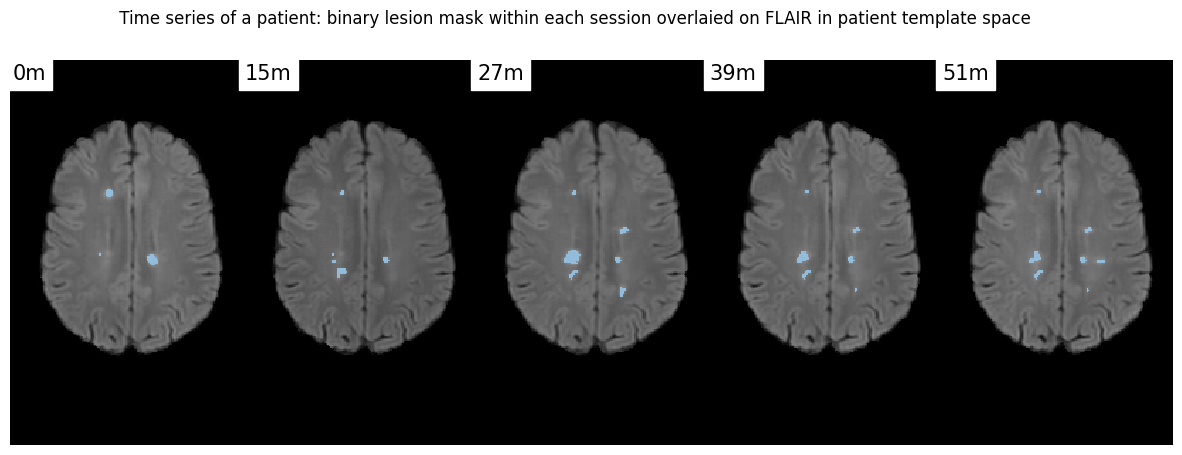

In [39]:
%matplotlib inline
sessions=['0m','15m','27m','39m','51m']
FLAIRS=[FLAIR_0m, FLAIR_15m, FLAIR_27m, FLAIR_39m, FLAIR_51m]
t2lmasks=[t2lmask_0m, t2lmask_15m, t2lmask_27m, t2lmask_39m, t2lmask_51m]

nrows=1
ncols=len(FLAIRS)
# cutc cut coords at axial slice
cutc=[47]
# create a subplot
fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(15, 5), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

#iterate over subplot axes
i=-1
for cols in range(ncols):
    i=i+1
    display= plot_roi(roi_img=t2lmasks[i], bg_img= FLAIRS[i], cut_coords= cutc, annotate=False, 
                draw_cross=False, axes=axes[cols], display_mode='z', cmap= cmap2, colorbar=False,
                radiological=False, title=sessions[cols], vmin=0,vmax=42, alpha=1)   
    for cut_ax in display.axes.values():
        cut_ax.ax.set_xlim(-80, 80)
        cut_ax.ax.set_ylim(-80, 150)    
fig.suptitle(" Time series of a patient: binary lesion mask within each session overlaid on FLAIR in patient template space")        
plt.show()

## 1) PyAFIL step 1: lesion density maks of all timepoints'

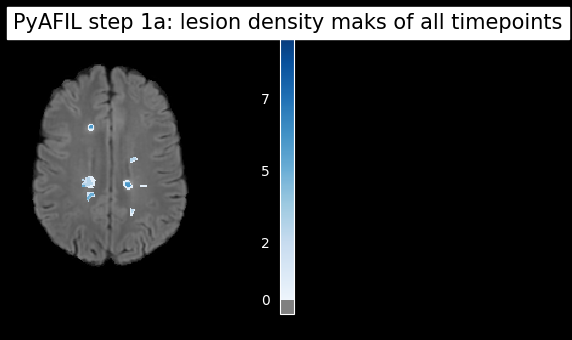

In [40]:
# AFIL creates a lesion density mask, which add all segmentations of all sessions into one.
# A higher value corresponds to voxels which are segmented as lesions during the session. This is used as global label reference.   
from nilearn.plotting import plot_roi, show
%matplotlib inline
# load lesion density mask
lesion_density_mask= nib.load(join(project_dir,'derivatives','density_mask',f'sub-{project.subjects[0]}',f'sub-{project.subjects[0]}_desc-density_mask.nii.gz'))
plot_roi(roi_img=lesion_density_mask, bg_img= FLAIR_0m, cut_coords= cutc, annotate=False, 
                draw_cross=False, display_mode='z', cmap='Blues',
                radiological=False, title='PyAFIL step 1a: lesion density maks of all timepoints', vmin=0, vmax=10, alpha=1,colorbar=True)


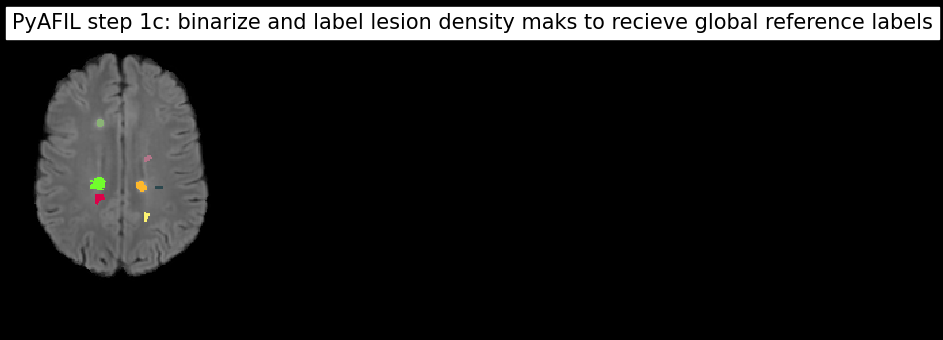

In [41]:
# AFIL creates a lesion density mask, which add all segmentations of all sessions into one.
# A higher value corresponds to voxels which are segmented as lesions during the session. This is used as global label reference.   
from nilearn.plotting import plot_roi, show
%matplotlib inline
# load lesion density mask
lesion_density_mask= nib.load(join(project_dir,'derivatives','density_mask',f'sub-{project.subjects[0]}',f'sub-{project.subjects[0]}_desc-glbreference_mask.nii.gz'))
plot_roi(roi_img=lesion_density_mask, bg_img= FLAIR_0m, cut_coords= cutc, annotate=False, 
                draw_cross=False, display_mode='z', cmap=cmap2,
                radiological=False, title='PyAFIL step 1c: binarize and label lesion density maks to recieve global reference labels', vmin=0, vmax=42, alpha=1,colorbar=False)


## 2) interim labeled lesion masks overlaid on FLAIR

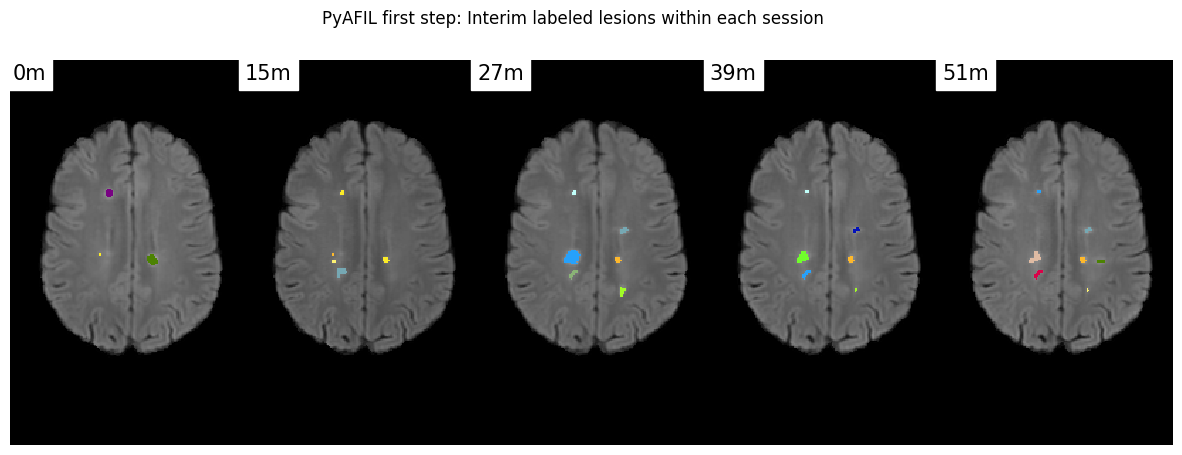

In [42]:


%matplotlib inline
sessions=['0m','15m','27m','39m','51m']
FLAIRS=[FLAIR_0m, FLAIR_15m, FLAIR_27m, FLAIR_39m, FLAIR_51m]
ilblmasks=[ilblmask_0m, ilblmask_15m, ilblmask_27m, ilblmask_39m, ilblmask_51m]

nrows=1
ncols=len(FLAIRS)
# cutc cut coords at axial slice
cutc=[47]
# create a subplot
fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(15, 5), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

#iterate over subplot axes
i=-1
for cols in range(ncols):
    i=i+1
    display= plot_roi(roi_img=ilblmasks[i], bg_img= FLAIRS[i], cut_coords= cutc, annotate=False, 
                draw_cross=False, axes=axes[cols], display_mode='z', cmap= cmap2, colorbar=False,
                radiological=False, title=sessions[cols], vmin=0,vmax=42, alpha=1)   
    for cut_ax in display.axes.values():
        cut_ax.ax.set_xlim(-80, 80)
        cut_ax.ax.set_ylim(-80, 150)    
fig.suptitle("PyAFIL first step: Interim labeled lesions within each session")        
plt.show()

## 3) globally labeled lesion masks overlaid on FLAIR

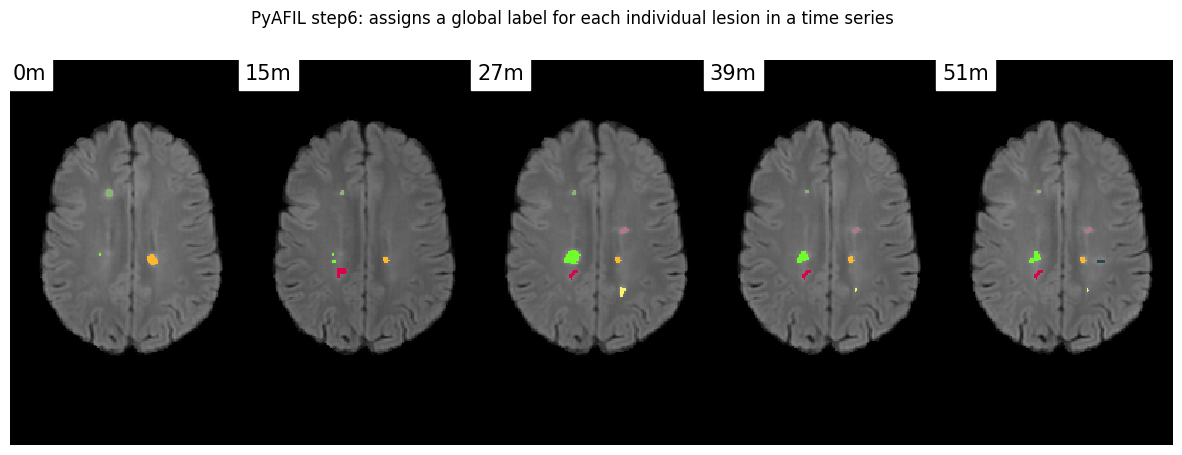

In [43]:
# shows FLAIR and global labeled lesion map (AFIL)

%matplotlib inline
sessions=['0m','15m','27m','39m','51m']
FLAIRS=[FLAIR_0m, FLAIR_15m, FLAIR_27m, FLAIR_39m, FLAIR_51m]
glblmasks=[glblmask_0m, glblmask_15m, glblmask_27m, glblmask_39m, glblmask_51m]

nrows=1
ncols=len(FLAIRS)
# cutc cut coords at axial slice
# create a subplot
fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(15, 5), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

#iterate over subplot axes
i=-1
for cols in range(ncols):
    i=i+1
    display= plot_roi(roi_img=glblmasks[i], bg_img= FLAIRS[i], cut_coords= cutc, annotate=False, 
                draw_cross=False, axes=axes[cols], display_mode='z', cmap=cmap2, colorbar=False,
                radiological=False, title=sessions[cols], vmin=0, vmax=42, alpha=1)   
    for cut_ax in display.axes.values():
        cut_ax.ax.set_xlim(-80, 80)
        cut_ax.ax.set_ylim(-80, 150)            
fig.suptitle("PyAFIL step6: assigns a global label for each individual lesion in a time series") 
plt.show()

In [44]:
# PyAFIL exports an excel sheat for every patient into derivatives/lesion_stats, containing all tracked labels (glbl) for all sessions. PyAFIL provide descriptive statistics 
# for every glbl for all specified maps. In this example lesions stats are provided for ervery glbl for FLAIR, T1w and MWF map.     
df_long= pd.read_excel(join(project_dir,'derivatives','lesion_stats',f'sub-{project.subjects[0]}_desc-longitudinal_label-glbl_lesionstats.xlsx'))
df_long['subject_id']= project.subjects[0]
df_long

,glbl,volume,map,mean,std,median,1_quantile,3_quantile,min,max,new,vanished,session,month,subject_id
0,1,14,mwf,0.223875,0.028721,0.230322,0.204389,0.248885,0.166893,0.256943,NaN,NaN,0m,0,DEV027
1,1,14,FLAIR,442.362693,22.173321,449.271515,423.684967,456.151505,400.381470,476.646729,NaN,NaN,0m,0,DEV027
2,1,14,T1w,795.931540,23.869767,799.145355,777.470459,812.958847,752.668945,830.887695,NaN,NaN,0m,0,DEV027
3,33,8,mwf,0.131594,0.029767,0.132942,0.112831,0.150352,0.087039,0.172461,NaN,NaN,0m,0,DEV027
4,33,8,FLAIR,478.336796,19.287442,485.118744,463.175667,494.494102,444.748383,500.934814,NaN,NaN,0m,0,DEV027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,41,27,FLAIR,413.679966,20.266827,410.742401,398.445694,435.744156,379.825043,449.898743,NaN,NaN,51m,51,DEV027
557,41,27,T1w,739.372541,19.963573,740.346741,729.152557,752.756592,694.886230,788.934326,NaN,NaN,51m,51,DEV027
558,42,4,mwf,0.260172,0.000344,0.260309,0.260069,0.260411,0.259597,0.260472,NaN,NaN,51m,51,DEV027
559,42,4,FLAIR,347.602348,14.993315,346.902145,333.731697,360.772797,331.040344,365.564758,NaN,NaN,51m,51,DEV027


In [45]:
# display MWF development for all globaly labeled lesions of the patient
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure()
plt.rcParams["figure.figsize"] = (10,5)

df_MWF = df_long.query('map == "mwf"')
df_MWF = df_MWF.dropna(subset=['map'])

<Figure size 640x480 with 0 Axes>

(0.0, 0.26)

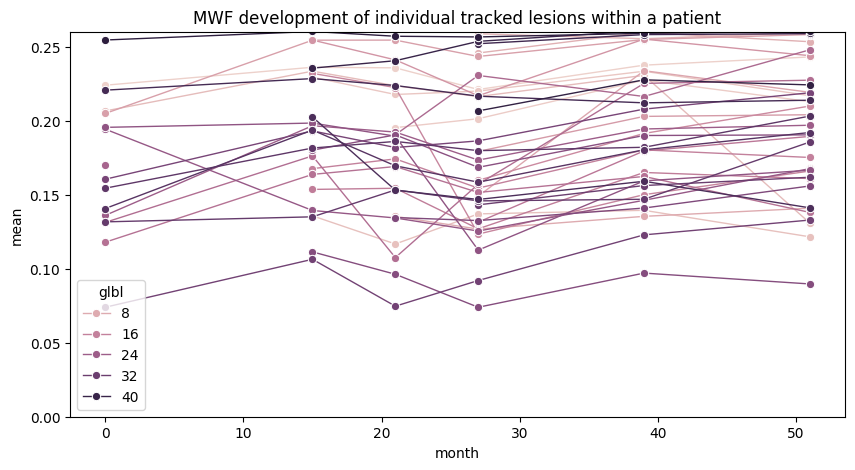

In [46]:
# Example patient MWF development in tracked lesions
g= sns.lineplot(x='month', y="mean", data= df_MWF, hue='glbl',  linewidth=1, marker='o',markers=True)
plt.title('MWF development of individual tracked lesions within a patient')
plt.ylim(0,0.26)